## 3. MACHINE LEARNING FOR CLASSIFICATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

df = pd.read_csv('telco_customer_churn.csv', sep=',')

print(f'columns: {df.shape[1]}\nrows: {df.shape[0]}')
display(df.head(2).T)
display(df.describe().T)
##display(df.dtypes)

columns: 21
rows: 7043


,0,1
customerID,7590-VHVEG,5575-GNVDE
gender,Female,Male
SeniorCitizen,0,0
Partner,Yes,No
Dependents,No,No
tenure,1,34
PhoneService,No,Yes
MultipleLines,No phone service,No
InternetService,DSL,DSL
OnlineSecurity,No,Yes


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### 3.2 DATA PREPARATION

In [2]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
string_list = list(df.dtypes[df.dtypes == 'str'].index)

for col in string_list:
    df[col] = df[col].str.lower().str.replace(' ', '_').str.replace('-', '_')

# column example with string value that should be numeric
# let fix it by replacing with 0 and then convert to numeric
display(df[df.index == 488].T)

df['totalcharges'] = pd.to_numeric(df['totalcharges'].replace('_', '0'), errors='coerce')
df['monthlycharges'] = pd.to_numeric(df['monthlycharges'].replace('_', '0'), errors='coerce')
df['seniorcitizen'] = df['seniorcitizen'].astype(int).replace(0, 'no').replace(1, 'yes').astype(str)

#df['CHURN'] = df['CHURN'].map({'yes': 1, 'no': 0})
df['churn'] = (df['churn'] == 'yes').astype(int)

,488
customerid,4472_lvygi
gender,female
seniorcitizen,0
partner,yes
dependents,yes
tenure,0
phoneservice,no
multiplelines,no_phone_service
internetservice,dsl
onlinesecurity,yes


### 3.3 SETTING THE VALIDATION FRAMEWORK

In [3]:
# split the data into 80% train, 20% test, 20% of the train will be used as validation
# 20% of 80% is 16% of the total data
# so we use 20%/80% = 25% of the train data as validation
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['churn']
y_val = df_val['churn']
y_test = df_test['churn']

X_train = df_train.drop(columns=['churn'])
X_val = df_val.drop(columns=['churn'])
X_test = df_test.drop(columns=['churn'])

print(f'train: {len(df_train)}')
print(f'validation: {len(df_val)}')
print(f'test: {len(df_test)}')
display((y_train.value_counts(normalize=True)*100).round(2))

train: 4225
validation: 1409
test: 1409


churn
0    73.14
1    26.86
Name: proportion, dtype: float64

In [4]:
categorical_columns = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
categorical_columns.remove('customerid')
numerical_columns = X_train.select_dtypes(exclude=['object', 'category', 'str']).columns.tolist()

display(X_train[numerical_columns].head(3).T)
display(X_train[categorical_columns].head(3).T)

,0,1,2
tenure,72.00,10.00,5.00
monthlycharges,115.50,95.25,75.55
totalcharges,8425.15,1021.55,413.65


,0,1,2
gender,female,male,female
seniorcitizen,no,no,no
partner,yes,no,no
dependents,yes,no,no
phoneservice,yes,yes,yes
multiplelines,yes,yes,yes
internetservice,fiber_optic,fiber_optic,fiber_optic
onlinesecurity,yes,no,no
onlinebackup,yes,yes,no
deviceprotection,yes,yes,no


### 3.5 FEATURE IMPORTANCE: CHURN RATE AND RISK RATIO

#### 3.5.1 CHURN RATE

In [5]:
## GLOBAL CHURN
global_churn = df_full_train['churn'].mean()

## GENDER CHURN
churn_male = df_full_train[df_full_train['gender'] == 'male']['churn'].mean()
churn_female = df_full_train[df_full_train['gender'] == 'female']['churn'].mean()
print(f'female churn: {churn_female:.2%}\nmale churn: {churn_male:.2%}\nglobal churn: {global_churn:.2%}\n')

## PARTNER CHURN
churn_partner_yes = df_full_train[df_full_train['partner'] == 'yes']['churn'].mean()
churn_partner_no = df_full_train[df_full_train['partner'] == 'no']['churn'].mean()
print(f'partner yes churn: {churn_partner_yes:.2%}\npartner no churn: {churn_partner_no:.2%}\npartner global churn: {global_churn:.2%}\n')

female churn: 27.68%
male churn: 26.32%
global churn: 27.00%

partner yes churn: 20.50%
partner no churn: 32.98%
partner global churn: 27.00%



The following snippet displays the value of the global **churn rate**. In comparison to that value, we can also calculate the churn rates for the **female** and **male** groups. We observe that the female churn rate is slightly higher than the global rate, while the male churn rate is slightly lower than the global rate.

When examining **partner** group, we notice that customers with partners are significantly less likely to churn. The churn rate for this group is **approximately 20%**, contrasting with the global churn rate of **almost 27%**. On the other hand, customers without partners have a much higher churn rate compared to the global rate, **standing at 33%** as opposed to 27%.

This observation suggests that the **partner variable may be more influential** for predicting churn **than the gender variable**.

### 3.5.2 RISK RATIO

In the context of machine learning and classification, the “risk ratio” typically refers to a statistical measure used to assess the likelihood or probability of a certain event occurring in one group compared to another. It’s a useful concept in various fields, including healthcare, finance, and customer churn analysis.

In the specific context of churn rate, the risk ratio can help you understand the relative risk of churn (i.e., customers leaving) for different groups or segments within your dataset. It can provide insights into which features or factors are associated with a higher or lower risk of churn.

Here’s a simplified explanation of how risk ratio works in the context of churn rate:

>**1. Definition of Risk Ratio**: The risk ratio (also known as the relative risk) is defined as the probability of an event occurring in one group divided by the probability of the same event occurring in another group. In the case of churn rate, you’re typically comparing two groups: one group that exhibits a certain characteristic or behavior (e.g., customer has churned) and another group that does not exhibit that characteristic (e.g., customer hasn’t churned).

>**2. Interpretation**: A risk ratio greater than 1 suggests that the event (churn in this case) is more likely in the first group compared to the second group. A risk ratio less than 1 suggests the event is less likely in the first group. A risk ratio equal to 1 means there is no difference in risk between the two groups.

>**3. Application**: We can use risk ratios to assess the impact of different features or interventions on churn rate. For example, we might calculate the risk ratio of churn for customers who received a promotional offer versus those who did not. If the risk ratio is significantly greater than 1, it indicates that the promotional offer had a positive impact on reducing churn.

>**4. Statistical Significance**: It’s important to also consider statistical significance when interpreting risk ratios. Statistical tests such as chi-squared tests or confidence intervals can help determine if the observed differences in churn rates are statistically significant.

So the risk ratio is a valuable tool for assessing the impact of different factors or features on churn rate in classification tasks. It helps you quantify and compare the relative risk of churn between different groups, providing insights that can inform decision-making and strategies for reducing churn.

Let’s compare the risk ratio for churning between people with partners and those without partners.

In [6]:
print(f'partner no churn ratio: {churn_partner_no / global_churn:.2%}')
print(f'partner yes churn ratio: {churn_partner_yes / global_churn:.2%}')

partner no churn ratio: 122.17%
partner yes churn ratio: 75.95%


This demonstrates that the churn rate for **people without partners is 22% higher, whereas for people with partners, it is 24% lower than the global churn rate**.

Let’s take the data and group it by gender, and for each variable within the gender group, let’s calculate the average churn rate within that group and calculate the difference and risk. We can perform this analysis for all the variables, not just the gender variable.

In [7]:
df_full_train.groupby('partner')['churn'].mean()
df_full_train.groupby('partner')['churn'].agg(['mean', 'count'])

,mean,count
partner,,
no,0.329809,2932
yes,0.205033,2702


In [8]:
for col in categorical_columns:
    df_group = df_full_train.groupby(col)['churn'].agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


,mean,count,diff,risk
seniorcitizen,,,,
no,0.242270,4722,-0.027698,0.897403
yes,0.413377,912,0.143409,1.531208


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412


...

,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182


,mean,count,diff,risk
contract,,,,
month_to_month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


Concerning the difference, we calculate it as the group’s churn rate minus the global churn rate **_(Δ churn = group - global)_**. This metric represents the **absolute deviation in percentage points (p.p.)** from the overall average.

- **Positive values (> 0)** indicate that the group has a higher churn rate than the global average (worse performance).

- **Negative values (< 0)** indicate that the group has a lower churn rate than the global average (better performance).

The magnitude of the value reflects **how far the group is from the average in absolute terms**.

This metric is particularly useful for identifying **which groups contribute most to overall churn deterioration**, as it captures real impact in percentage points rather than proportional differences.

_It is important to note that this measure is descriptive, not causal: it indicates whether a group is above or below the average, but does not, by itself, explain why the difference exists._

For a more complete analysis, this metric is often used alongside the relative ratio (group / global), which captures proportional deviation. While the difference highlights absolute impact, the ratio highlights relative intensity, and both should be interpreted together for better decision-making.

---

As for the **risk ratio**, it is obtained by **dividing the group’s churn rate by the global churn rate _(risk ratio = group / global)_**. This metric represents the **relative deviation from the overall average**.

- **Values greater than 1 (> 1)** indicate that the group has a higher churn rate than the global average (worse performance).

- **Values less than 1 (< 1)** indicate that the group has a lower churn rate than the global average (better performance).

- A value of **exactly 1 indicates that the group is aligned** with the global average.

The **risk ratio captures how many times higher (or lower) the churn rate is relative to the baseline**. For example, a value of 1.5 means the group’s churn rate is 50% higher than average, while 0.8 indicates it is 20% lower than average.

_It is important to emphasize that, similarly to the difference metric, the risk ratio is descriptive rather than causal. It reflects how a group compares to the average, but does not explain the underlying drivers of churn._

---

In essence, both difference (group − global) and risk ratio (group / global) convey related information from complementary perspectives:

>`The difference measures absolute impact (in percentage points)`

>`The risk ratio measures relative intensity (proportional change)`

Using both together provides a more complete understanding of how each group behaves compared to the overall population.

By analyzing these metrics across categories, **we can identify which groups systematically deviate from the global churn behavior** - either positively or negatively. These group-level patterns highlight **potentially relevant features for churn analysis and modeling**.

However, evaluating categories in isolation is not sufficient to determine the overall importance of a variable. A variable may show strong deviations in some categories but still have limited impact at the population level (for example, if those categories are small).

To compare variables such as “contract” and “streamingmovies” in terms of their overall relevance, we need a more aggregated measure of importance. This requires combining the magnitude of deviation with the distribution (size) of each group, which we will address in the next steps.

### 3.6 FEATURE IMPORTANCE: MUTUAL INFORMATION (CATEGORICAL)

#### Summary (main aspects):
This code calculates **how informative each categorical feature is for predicting the target variable `(churn)`**. It uses Mutual Information (MI) to rank features by their relevance.

#### Main concept — Mutual Information:
Mutual Information measures how much knowing a feature reduces uncertainty about the target.

Higher value > stronger relationship with churn
Near zero > little to no predictive power

What the code does:

1. Defines a function to compute MI between a feature and churn
2. Applies it to all categorical columns
3. Sorts results from most to least important

In [9]:
def mutual_information_score(series):
    return mutual_info_score(series, df_full_train.churn)

mutual_information = df_full_train[categorical_columns].apply(mutual_information_score).sort_values(ascending=False)
mutual_information

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### **Result interpretation (key takeaway)**:

- Most important features: `contract`, `onlinesecurity`, `techsupport`, `internetservice`
- Least useful features: `gender`, `phoneservice`, `multiplelines`

In practice: focus modeling and analysis on top features, as they carry most of the predictive signal for churn.

### 3.7 FEATURE IMPORTANCE: CORRELATION (NUMERICAL)

#### Summary (main aspects):
This code evaluates how numerical features relate to churn using correlation. It shows both the direction (positive/negative) and the strength (absolute value).

#### Main concept - Correlation:
Correlation measures the linear relationship between a variable and the target:

- Positive > higher value > higher chance of churn
- Negative > higher value > lower chance of churn
- Absolute value > strength of the relationship (ignores direction)

What the code does:

1. Computes correlation between each numerical feature and churn
2. Sorts once by actual value (to see direction)
3. Sorts again by absolute value (to see importance)

In [10]:
display(df_full_train[numerical_columns].corrwith(df_full_train['churn']).sort_values(ascending=True))
display(df_full_train[numerical_columns].corrwith(df_full_train['churn']).abs().sort_values(ascending=False))

tenure           -0.351885
totalcharges     -0.196353
monthlycharges    0.196805
dtype: float64

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

#### **Result interpretation (key takeaway)**:

- Strongest feature: tenure (negative > longer customers churn less)
- Moderate impact: monthlycharges (positive > higher charges increase churn)
- Moderate impact: totalcharges (negative > higher total spend reduces churn)

In practice: tenure is the most influential numerical driver, while pricing-related variables also play a relevant role.

In [11]:
display(df_full_train[numerical_columns].max())

tenure              72.00
monthlycharges     118.65
totalcharges      8684.80
dtype: float64

In [12]:
monthly_charges_ranges = [[0, 20],
                          [20, 50],
                          [50, 70],
                          [70, 90],
                          [90, 120],
                          [50, 120]] # 50 to 120 because the max is 118.75

tenure_ranges = [[0, 2],
                 [2, 12],
                 [12, 24],
                 [24, 48],
                 [48, 72],
                 [12, 72]] # 12 to 72 because the max is 72

for start, end in tenure_ranges:
    churn_rate = df_full_train[(df_full_train['tenure'] > start) &
                               (df_full_train['tenure'] <= end)]['churn'].mean()
    print(f"tenure range [{start}, {end}] months: {churn_rate * 100:.4f}%")

print()

for start, end in monthly_charges_ranges:
    churn_rate = df_full_train[(df_full_train['monthlycharges'] > start) &
                               (df_full_train['monthlycharges'] <= end)]['churn'].mean()
    print(f"monthly charges range [{start}, {end}] dollars: {churn_rate * 100:.4f}%")

tenure range [0, 2] months: 60.2356%
tenure range [2, 12] months: 39.9441%
tenure range [12, 24] months: 30.1724%
tenure range [24, 48] months: 20.4651%
tenure range [48, 72] months: 9.8250%
tenure range [12, 72] months: 17.6349%

monthly charges range [0, 20] dollars: 8.7954%
monthly charges range [20, 50] dollars: 18.3409%
monthly charges range [50, 70] dollars: 21.8143%
monthly charges range [70, 90] dollars: 38.5135%
monthly charges range [90, 120] dollars: 33.2135%
monthly charges range [50, 120] dollars: 32.4993%


#### Result interpretation (key takeaway):

**Tenure (very strong pattern)**:

- Early customers churn a lot:
>- 0–2 months > ~60%
>- 2–12 months > ~40%

- Long-term customers are stable:
>- 48–72 months > ~10%

**Clear insight**: the longer the customer stays, the lower the churn

**Monthly Charges (non-linear pattern)**:

- Low price > low churn (~9%)
- Mid-range > moderate churn (~18–22%)
 -High price > peak churn (~33–38%)

**Insight**: churn increases significantly with higher pricing, but not perfectly linearly

**Practical takeaway**:

>1. tenure is a lifecycle variable (retention improves over time)
>2. monthlycharges is a pricing sensitivity variable (higher cost > higher risk)

These bins are especially useful for:

Business rules (e.g., early retention campaigns)
Feature engineering (turning numeric into categorical segments)

### 3.8 ONE-HOT ENCODING

#### Summary (main aspects):
This code converts all features into a numerical matrix using One-Hot Encoding, preparing the data for machine learning models.

**Main concept — One-Hot Encoding**:
Categorical variables are transformed into binary columns (0/1):

Each category becomes a new feature
Example: contract = "month-to-month" > contract_month-to-month = 1, others = 0

>This allows models to understand categorical data numerically

**What the code does**:

1. Creates a DictVectorizer to handle encoding
2. Converts train and validation data into dictionaries
3. Fits + transforms on training data (learns categories)
4. Transforms only on validation data (keeps same structure)

Key takeaway:

- Ensures consistent feature representation between train and validation
- Converts all data into a format usable by ML algorithms
- Prevents data leakage by fitting only on training data

In practice: this step is essential to turn raw data into a model-ready feature matrix

In [13]:
dv = DictVectorizer(sparse=False)

train_dict = X_train[categorical_columns + numerical_columns].to_dict(orient='records')
X_train_encoded = dv.fit_transform(train_dict)

val_dict = X_val[categorical_columns + numerical_columns].to_dict(orient='records')
X_val_encoded = dv.transform(val_dict)

In [14]:
#display(list(dv.get_feature_names_out()))
#display(train_dict[0])

### 3.9 LOGISTIC REGRESSION

In [15]:
## DEFINITION
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## EXAMPLE
example = np.linspace(-25, 25, 20)
print('=== BEFORE SIGMOID TRANSFORMATION ===')
display(print(example.round(4)))

print('=== AFTER SIGMOID TRANSFORMATION ===')
display(print(sigmoid(example).round(4)))

#plt.plot(example, sigmoid(example))

=== BEFORE SIGMOID TRANSFORMATION ===
[-25.     -22.3684 -19.7368 -17.1053 -14.4737 -11.8421  -9.2105  -6.5789
  -3.9474  -1.3158   1.3158   3.9474   6.5789   9.2105  11.8421  14.4737
  17.1053  19.7368  22.3684  25.    ]


None

=== AFTER SIGMOID TRANSFORMATION ===
[0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e-04
 1.400e-03 1.890e-02 2.115e-01 7.885e-01 9.811e-01 9.986e-01 9.999e-01
 1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]


None

At the end of this article, both implementations are presented for comparison. The first snippet demonstrates the familiar linear regression, while the second snippet illustrates logistic regression.

It’s evident that there is essentially only one difference between the two: in logistic regression, the sigmoid function is applied to the result of the linear regression to transform it into a probability value between 0 and 1.

In [16]:
# # linear_regression
# [...]

# for j in range(len(w)):
#     result = result + xi[j] * w[j]

# return result

# [...]

# # logistic_regression
# [...]

# for j in range(len(w)):
#     score = score + xi[j] * w[j]

# result = sigmoid(score)
# return result

# [...]

### 3.10 TRAINING LOGISTIC REGRESSION

In [17]:
lr = LogisticRegression()
lr.fit(X_train_encoded, y_train)

intercept = lr.intercept_[0].round(5)
coef = lr.coef_[0].round(3)

display(intercept)
display(coef)

print(f'HARD PREDICTIONS:\n{lr.predict(X_train_encoded)}')
print()
print(f'SOFT PREDICTIONS:\n{lr.predict_proba(X_train_encoded).round(3)}')

np.float64(-0.09428)

array([ 0.556, -0.152, -0.496, -0.013, -0.08 ,  0.078, -0.09 , -0.081,
       -0.024, -0.069, -0.335,  0.332, -0.09 ,  0.003, -0.254,  0.174,
       -0.013,  0.073, -0.09 , -0.076,  0.264, -0.09 , -0.266, -0.224,
        0.131, -0.115,  0.022, -0.091, -0.027,  0.055, -0.03 ,  0.174,
       -0.267, -0.131,  0.039, -0.09 , -0.09 ,  0.087, -0.042, -0.09 ,
        0.039,  0.207, -0.09 , -0.21 , -0.072,  0.   ])

HARD PREDICTIONS:
[0 1 1 ... 1 0 1]

SOFT PREDICTIONS:
[[0.908 0.092]
 [0.326 0.674]
 [0.357 0.643]
 ...
 [0.487 0.513]
 [0.969 0.031]
 [0.305 0.695]]


In [18]:
# let's create our own churn classification based on predicted probabilities
# we will use the second column from the predict_proba output (probability of churn = class 1)
# a threshold of 0.5 will be used to classify whether a customer is likely to churn

# predicted probability of churn (class 1)
y_pred_proba = lr.predict_proba(X_val_encoded)[:, 1]

# apply classification threshold
threshold = 0.5
y_pred = y_pred_proba >= threshold

print(y_pred)

[False False False ... False  True  True]


In [19]:
churn_decision = y_pred

print(f'promotions that will be sent (df_val): {df_val[churn_decision].value_counts().sum()}')
df_val[churn_decision]['customerid']

accuracy_score = ((y_val == churn_decision).mean().round(4) * 100)
print(f'accuracy_score: {accuracy_score}%')

promotions that will be sent (df_val): 323
accuracy_score: 79.91%


In [20]:
df_pred = pd.DataFrame()
df_pred['churn prob'] = (y_pred_proba * 100).round(2).astype('str') + '%'
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val
df_pred['correct'] = df_pred['prediction'] == df_pred['actual']

df_pred[df_pred['correct'] == False]

,churn prob,prediction,actual,correct
9,48.71%,0,1,False
11,50.6%,1,0,False
14,7.12%,0,1,False
22,23.53%,0,1,False
27,21.84%,0,1,False
...,...,...,...,...
1380,20.46%,0,1,False
1386,43.89%,0,1,False
1391,45.49%,0,1,False
1393,61.21%,1,0,False


### 3.11 MODEL INTERPRETATION

In [21]:
dict_coefs = dict(zip(dv.get_feature_names_out(), lr.coef_[0].round(3)))
dict_coefs

{'contract=month_to_month': np.float64(0.556),
 'contract=one_year': np.float64(-0.152),
 'contract=two_year': np.float64(-0.496),
 'dependents=no': np.float64(-0.013),
 'dependents=yes': np.float64(-0.08),
 'deviceprotection=no': np.float64(0.078),
 'deviceprotection=no_internet_service': np.float64(-0.09),
 'deviceprotection=yes': np.float64(-0.081),
 'gender=female': np.float64(-0.024),
 'gender=male': np.float64(-0.069),
 'internetservice=dsl': np.float64(-0.335),
 'internetservice=fiber_optic': np.float64(0.332),
 'internetservice=no': np.float64(-0.09),
 'monthlycharges': np.float64(0.003),
 'multiplelines=no': np.float64(-0.254),
 'multiplelines=no_phone_service': np.float64(0.174),
 'multiplelines=yes': np.float64(-0.013),
 'onlinebackup=no': np.float64(0.073),
 'onlinebackup=no_internet_service': np.float64(-0.09),
 'onlinebackup=yes': np.float64(-0.076),
 'onlinesecurity=no': np.float64(0.264),
 'onlinesecurity=no_internet_service': np.float64(-0.09),
 'onlinesecurity=yes': n

In [22]:
import numpy as np

def predict_manual(features, coefs, intercept):
    """
    Compute and display the manual prediction of a logistic regression model.

    This function reconstructs the linear combination (log-odds) using selected
    features and their coefficients, prints a step-by-step breakdown of each
    contribution, and calculates the final probability using the sigmoid function.

    Parameters
    ----------
    features: dict
    Dictionary with feature names as keys and their corresponding values.
    Example: {'tenure': 12, 'contract=month_to_month': 1}
    
    coefs: dict
    Dictionary mapping feature names to their logistic regression coefficients.
    
    intercept: float
    Intercept (bias term) of the trained logistic regression model.

    Returns: The function prints intermediate steps and the final probability.
    
    Notes
    -----
    - Assumes one-hot encoded features (only one category per group should be 1).
    - Useful for interpretability, debugging, and what-if scenario analysis.
    
    """

    z = intercept
    
    # begin the equation with the intercept
    equation = f"{intercept:.5f}"
    
    print(f"Intercept: {intercept:.5f}\n")

    for k, v in features.items():
        weight = coefs.get(k, 0)
        contribution = weight * v
        
        print(f"Feature: {k}")
        print(f"Value: {v}")
        print(f"Weight: {weight}")
        print(f"Contribution: {weight} * {v} = {contribution:.5f}\n")
        
        z += contribution
        
        # build the equation in a legible format
        equation += f" + ({weight:.3f} * {v})"

    # final result of linear equation
    print("Linear equation (z):")
    print(f"z = {equation}")
    print(f"z = {z:.5f}\n")

    # sigmoid
    prob = 1 / (1 + np.exp(-z))
    
    print("Sigmoid:")
    print(f"P(churn) = 1 / (1 + e^(-{z:.5f}))")
    print(f"P(churn) = {prob:.4f} ({prob*100:.2f}%)")

In [23]:
cliente = {
    'contract=month_to_month': 1,
    'tenure': 4,
    'monthlycharges': 70
}

predict_manual(cliente, dict_coefs, intercept)

Intercept: -0.09428

Feature: contract=month_to_month
Value: 1
Weight: 0.556
Contribution: 0.556 * 1 = 0.55600

Feature: tenure
Value: 4
Weight: -0.072
Contribution: -0.072 * 4 = -0.28800

Feature: monthlycharges
Value: 70
Weight: 0.003
Contribution: 0.003 * 70 = 0.21000

Linear equation (z):
z = -0.09428 + (0.556 * 1) + (-0.072 * 4) + (0.003 * 70)
z = 0.38372

Sigmoid:
P(churn) = 1 / (1 + e^(-0.38372))
P(churn) = 0.5948 (59.48%)


In [24]:
#print(f'{-0.09428 + (0.556 * 1) + (-0.072 * 4) + (0.003 * 70):.4f}')
#print(f"{(sigmoid(-0.09428 + (0.556 * 1) + (-0.072 * 4) + (0.003 * 70)) * 100):.2f}%")

---
#### Interpreting the Bias and Coefficients in Logistic Regression

This example shows how the prediction is built step by step using the intercept (bias term) and feature coefficients.

The **`intercept`** represents the baseline tendency to churn when all features are zero. In this case, the baseline log-odds are slightly negative, indicating a lower initial probability of churn.

Each **`feature`** adjusts the prediction based on its value and weight:

1. **Intercept `(-0.09428)`**
2. **Feature Contributions**

>- **contract=month_to_month `(+0.556)`**: Strong positive impact > increases churn probability significantly
>- **tenure `(-0.072 per unit)`**: Negative relationship > longer tenure reduces churn. For 4 months: -0.288 total impact
>- **monthlycharges `(+0.003 per unit)`**: Small positive effect > higher charges slightly increase churn. For 70 units: +0.210 total impact.

3. Final Linear Combination (z)

All contributions are summed with the intercept: **`z = 0.38372`**

Probability (Sigmoid Transformation)
The linear result is converted into probability: **`P(churn) = 59.48%`**

---

**Key Takeaways**
- The intercept sets the baseline, but features drive the final prediction
- Positive coefficients increase churn probability, while negative ones decrease it
- The magnitude of (coefficient x value) determines the real impact
- This breakdown allows clear interpretation and what-if analysis for each variable

### 3.12 USING THE MODEL

In [25]:
y_full_train = df_full_train['churn'].values
X_full_train = df_full_train[categorical_columns + numerical_columns].reset_index(drop=True)
# we have already defined X_test and y_test

dicts_full_train = df_full_train[categorical_columns + numerical_columns].to_dict(orient='records')
dicts_test = df_test[categorical_columns + numerical_columns].to_dict(orient='records')

#display(X_full_train.head())
#display(y_full_train.head())

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)
X_test = dv.fit_transform(dicts_test)

lr = LogisticRegression()
lr.fit(X_full_train, y_full_train)
y_pred_full = lr.predict_proba(X_test)[:, 1]

In [26]:
churn_decision_full = (y_pred_full >= 0.5)
print(f'ACCURACY: {float((churn_decision_full == y_test).mean()) * 100:.2f}%')

ACCURACY: 81.41%


In [27]:
# let's make some predictions using random customer examples

number_customer = 1408
customer = dicts_test[number_customer]
X_customer = dv.transform([customer])

print(f'CALC_PROB_CHURN: {float(lr.predict_proba(X_customer)[0, 1]) * 100:.2f}%')
print(f'y_test(churn) value: {'no' if y_test[number_customer] == 0 else 'yes'}')
display(customer)

CALC_PROB_CHURN: 66.78%
y_test(churn) value: yes


{'gender': 'female',
 'seniorcitizen': 'no',
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month_to_month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

### 4 METRICS

#### 4.1 ACCURACY

**Accuracy** = fraction of correct predictions over total predictions.

In [28]:
accuracy_score = ((y_val == churn_decision).mean().round(4) * 100)
print(f'accuracy_score: {accuracy_score}%')

accuracy = (y_val == churn_decision).mean()

# or equivalently:
threshold = 0.5

predict_positive = (y_pred >= threshold)
predict_negative = (y_pred < threshold)
actual_positive  = (y_val == 1)
actual_negative  = (y_val == 0)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

accuracy_score = (tp + tn) / (tp + tn + fp + fn)
print(f'accuracy_score: {accuracy_score * 100:.2f}%')

accuracy_score: 79.91%
accuracy_score: 79.91%


#### Is 80% Accuracy Good?

Not necessarily. Accuracy must be interpreted in context:

It depends on:
- Class distribution (e.g., imbalance)
- Business impact of errors (false positives vs false negatives)
- A dummy (baseline) model is often used for comparison:
>Example: always predicting the majority class

If your model is not significantly better than a dummy model, it may not be useful.

#### Evaluate the model on different thresholds

The default threshold (0.5) is arbitrary and may not be optimal. We can evaluate performance across multiple thresholds:

In [29]:
thresholds = np.linspace(0, 1, 21)
print(f'{thresholds}\n')

scores = []
 
for t in thresholds:
    churn_decision = (y_pred_proba >= t)
    score = (y_val == churn_decision).mean()
    print('%.2f %.4f' % (t, score))
    scores.append(score)

#plt.plot(thresholds, scores)

[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]

0.00 0.2740
0.05 0.5089
0.10 0.5969
0.15 0.6636
0.20 0.7090
0.25 0.7374
0.30 0.7566
0.35 0.7651
0.40 0.7814
0.45 0.7906
0.50 0.7991
0.55 0.7991
0.60 0.7956
0.65 0.7850
0.70 0.7693
0.75 0.7417
0.80 0.7296
0.85 0.7260
0.90 0.7260
0.95 0.7260
1.00 0.7260


#### The Dummy Baseline Problem

A model that **always predicts the majority class** (no churn) gets ~73% accuracy — nearly "for free".

- Dataset: 73% non-churning, 27% churning → **class imbalance**
- Our model: 80% accuracy — only 7% better than doing nothing
- **Conclusion**: accuracy alone is a misleading metric when classes are imbalanced

In [30]:
from collections import Counter

print(f'{Counter(y_val)}\n')
print(f'y_val (not churn): {(1 - y_val.mean()) * 100:.2f}%')
print(f'y_val (churn): {(y_val.mean()) * 100:.2f}%')

Counter({0: 1023, 1: 386})

y_val (not churn): 72.60%
y_val (churn): 27.40%


In this example, the accuracy of the model is 80%, but a dummy model that predicts all customers as not churning achieves an accuracy of 73%. This highlights the issue with accuracy, as it doesn’t differentiate between different types of errors. In churn prediction, false negatives (predicting a customer won’t churn when they actually do) can be more costly than false positives (predicting a customer will churn when they won’t).

Choosing the most appropriate evaluation metric depends on the specific goals and requirements of the problem. For example, in cases where minimizing false negatives is crucial (e.g., in medical diagnoses or fraud detection), recall may be a more relevant metric than accuracy.

In [31]:
print(Counter(y_pred >= 1.0))
print(Counter(y_val))

Counter({np.False_: 1086, np.True_: 323})
Counter({0: 1023, 1: 386})


We can observe that there are significantly more non-churning customers than churning ones, with only 27% being churning customers and 73% being non-churning customers. This situation highlights a common challenge known as class imbalance, where one class has far more samples than the other.

In cases of class imbalance, the traditional accuracy metric can be misleading. For example, a dummy model that predicts the majority class for all samples can achieve a high accuracy simply by getting most of the samples right for the majority class. However, it will perform poorly in identifying the minority class (in this case, the churning customers), which is often more crucial to predict accurately.

To effectively address class imbalance and evaluate our model, we should consider alternative metrics such as:

- Precision: This metric measures the proportion of true positive predictions among all positive predictions. It is particularly useful when the cost of false positives is high.
- Recall: Recall measures the proportion of true positive predictions among all actual positive instances. It is valuable when the cost of false negatives is significant.
- F1-Score: The F1-Score is the harmonic mean of precision and recall, providing a balanced measure that considers both false positives and false negatives.
- Area Under the Receiver Operating Characteristic Curve (AUC-ROC): The ROC curve plots the true positive rate against the false positive rate at various threshold settings. The AUC-ROC score assesses the classifier’s ability to distinguish between the positive and negative classes, making it particularly useful for imbalanced datasets.

Selecting the appropriate evaluation metric depends on the specific goals and requirements of the problem. In cases of class imbalance, accurate identification of the minority class (churning customers) is crucial.

#### 4.2 CONFUSION TABLE / MATRIX

The confusion matrix breaks predictions into **4 categories**:

| | Predicted Negative `g(x) < t` | Predicted Positive `g(x) >= t` |
|---|---|---|
| **Actual Negative** `y=0` | True Negative (TN) | False Positive (FP) — *Type I error* |
| **Actual Positive** `y=1` | False Negative (FN) — *Type II error* | True Positive (TP) |

In [32]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
 
print(confusion_matrix)
print()
print(f'{(confusion_matrix / confusion_matrix.sum()).round(2)}')

[[913 110]
 [173 213]]

[[0.65 0.08]
 [0.12 0.15]]


We observe that we have more false negatives than false positives. False positives represent customers who receive the email even though they are not likely to churn, resulting in a loss of money due to unnecessary discounts. False negatives are customers who do not receive the email and end up leaving, causing financial losses as well. Both situations are undesirable.

#### 4.3 PRECISION & RECALL

Precision and Recall are essential metrics for evaluating binary classification models.

- **Precision** measures the fraction of **positive predictions that were correct**. In other words, it quantifies **how accurately the model predicts customers who are likely to churn**.
>Precision = True Positives / (# Positive Predictions) >> True Positives / (True Positives + False Positives)

- **Recall**, on the other hand, **quantifies the fraction of actual positive cases that were correctly identified** by the model. It assesses **how effectively the model captures all customers who are actually churning**.
>Recall = True Positives / (# Positive Observations) >> True Positives / (True Positives + False Negatives)

In summary, **_precision focuses on the accuracy of positive predictions_**, while **_recall emphasizes the model’s ability to capture all positive cases_**. These metrics are crucial for understanding the trade-offs between correctly identifying churning customers and minimizing false positives.

In [33]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f'>> accuracy: {accuracy * 100:.2f}%')

# "Of all the customers I flagged as churning, how many actually were?"
precision = tp / (tp + fp)
print(f'>> precision: {precision * 100:.2f}%')

# "Of all the customers who actually churned, how many did I catch?"
recall = tp / (tp + fn)
print(f'>> recall: {recall * 100:.2f}%')

# --> promotional email goes to 311 people, but 210 are actually going to churn (--> 33% are mistakes)
print(f'\nemail to {tp + fp}, but {tp} going to churn')
print(f'{(1 - (tp / (tp + fp))) * 100:.2f}% are mistakes')

print(f'{(1-recall) * 100:.2f}% missed of real churners')

>> accuracy: 79.91%
>> precision: 65.94%
>> recall: 55.18%

email to 323, but 213 going to churn
34.06% are mistakes
44.82% missed of real churners


#### TRADE-OFF SUMMARY

| Metric        | Focuses on                      | Formula             |
|---------------|---------------------------------|---------------------|
| **Precision** | Quality of positive predictions | `TP / (TP + FP)`    |
| **Recall**    | Coverage of actual positives    | `TP / (TP + FN)`    |
| **Accuracy**  | Overall correctness             | `(TP + TN) / total` |

**Key insight**: Precision and Recall trade off against each other.  
Lowering the threshold > more positives predicted: **higher recall, lower precision**.  
Raising the threshold > fewer positives predicted: **higher precision, lower recall**.

While accuracy can give a misleading impression of a model’s performance, metrics like precision and recall are much more informative, especially in situations with class imbalance. Precision and recall provide a more detailed understanding of how well the model is performing in identifying positive cases (in this case, churning customers).

In scenarios where correctly identifying specific cases is critical, such as identifying churning customers to prevent loss, precision and recall help us make more informed decisions and assess the trade-offs between correctly identifying positives and minimizing false positives or false negatives. So, relying solely on accuracy may not provide a complete picture of a model’s effectiveness for a particular task.

#### 4.4 ROC CURVES

**ROC (Receiver Operating Characteristic)** curves are a valuable tool for evaluating binary classification models, especially in scenarios where you want to assess the trade-off between false positives and true positives at different decision thresholds.

The ROC curve **visually represents the performance of a model by plotting the TPR (True Positive Rate or Sensitivity) against the FPR (False Positive Rate or 1 – Specificity) at various threshold settings**. The area under the ROC curve (AUC-ROC) is a summary measure of a model’s overall performance, with a higher AUC indicating better discrimination between positive and negative cases.

ROC curves help you make informed decisions about the choice of threshold that balances your priorities between **minimizing false positives (FPR) and maximizing true positives (TPR)** based on the specific context and requirements of your problem.

|                            | Predicted Negative `g(x) < t` | Predicted Positive `g(x) >= t` |                        |
|----------------------------|-------------------------------|--------------------------------|------------------------|
| **Negative Example** `y=0` | True Negative (TN)            | False Positive (FP)            | `FPR = FP / (TN + FP)` |
| **Positive Example** `y=1` | False Negative (FN)           | True Positive (TP)             | `TPR = TP / (FN + TP)` |

In [34]:
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

display(f'fpr: {fpr}')
display(f'tpr: {tpr}')
display(f'recall: {recall}')
# tpr = recall

'fpr: 0.10752688172043011'

'tpr: 0.5518134715025906'

'recall: 0.5518134715025906'

In [35]:
scores = []
thresholds = np.linspace(0, 1, 101)

for threshold in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred_proba >= threshold)
    predict_negative = (y_pred_proba < threshold)

    tp = (actual_positive & predict_positive).sum()
    tn = (actual_negative & predict_negative).sum()

    fp = (actual_negative & predict_positive).sum()
    fn = (actual_positive & predict_negative).sum()

    scores.append((threshold.round(2), tp, tn, fp, fn))


columns = ('threshold', 'tp', 'tn', 'fp', 'fn')
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = (df_scores['tp'] / (df_scores['tp'] + df_scores['fn'])).round(4)
df_scores['fpr'] = (df_scores['fp'] / (df_scores['fp'] + df_scores['tn'])).round(4)

print(df_scores[::10])

     threshold   tp    tn    fp   fn     tpr     fpr
0          0.0  386     0  1023    0  1.0000  1.0000
10         0.1  367   474   549   19  0.9508  0.5367
20         0.2  335   664   359   51  0.8679  0.3509
30         0.3  288   778   245   98  0.7461  0.2395
40         0.4  254   847   176  132  0.6580  0.1720
50         0.5  213   913   110  173  0.5518  0.1075
60         0.6  153   968    55  233  0.3964  0.0538
70         0.7   75  1009    14  311  0.1943  0.0137
80         0.8    5  1023     0  381  0.0130  0.0000
90         0.9    0  1023     0  386  0.0000  0.0000
100        1.0    0  1023     0  386  0.0000  0.0000


In [36]:
#plt.plot(df_scores['threshold'], df_scores['tpr'], label='TPR')
#plt.plot(df_scores['threshold'], df_scores['fpr'], label='FPR')

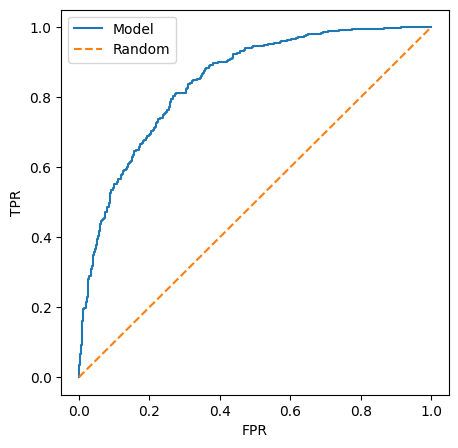

In [37]:
from sklearn.metrics import roc_curve
 
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
 
plt.figure(figsize=(5,5))
 
plt.plot(fpr, tpr, label='Model')
plt.plot([0,1], [0,1], label='Random', linestyle='--')
 
plt.xlabel('FPR')
plt.ylabel('TPR')
 
plt.legend()

In the curve of the ideal model, there is one crucial point, often referred to as the **‘north star’** or ideal spot, located **in the upper-left corner where TPR is 100% and FPR is 0%**. This point represents the optimal performance we aim to achieve with our model.

A ROC curve visualizes this by plotting TPR against FPR, and we usually add a diagonal random baseline. Our goal is to make our model’s curve as close as possible to this ideal spot, which means simultaneously being as far away as possible from the random baseline. In essence, if our model closely resembles the random baseline model, it is not performing well.

#### WHAT KIND OF INFORMATION DO WE GET FROM ROC CURVE?

The ROC curve shows how a model’s performance changes across different classification thresholds by plotting the trade-off between TPR (true positive rate) and FPR (false positive rate).

At a high threshold (e.g., 1.0), the model predicts no positives, so both TPR and FPR are 0. At a low threshold (e.g., 0.0), it predicts everything as positive, giving TPR = 1 but also FPR = 1.

As the threshold decreases, both TPR and FPR increase. Each point on the curve represents a specific threshold, allowing us to see how the model balances correctly identifying positives versus making false alarms.

The ROC curve helps evaluate and compare models: the closer the curve is to the top-left corner (high TPR, low FPR), the better. A related metric, AUC (Area Under the Curve), summarizes overall performance—the higher the AUC, the better the model.

#### 4.5 ROC-AUC - AREA UNDER THE ROC CURVE

AUC (Area Under the ROC Curve) measures how close a model is to the ideal classifier. An AUC of 0.5 represents a random model, while 1.0 indicates perfect performance, so a good model should fall between these values. If AUC is below 0.5, it usually means something is wrong (e.g., predictions are inverted). In practice, an **AUC around 0.8 is considered good, 0.9 is excellent, and 0.6 is relatively weak**.

In [38]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# arrays
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
print(auc(fpr, tpr))

# shortcut in scikit-learn
print(roc_auc_score(y_val, y_pred_proba))

0.8443797831228885
0.8443797831228885


### AUC INTERPRETATION

AUC tells us the probability that a randomly selected positive example has a score that is higher than a randomly selected negative example.

In [39]:
import random

neg = y_pred_proba[y_val == 0]
pos = y_pred_proba[y_val == 1]

In [40]:
# we want to compare the score of this positive example
# with the score of the negative example
neg_ind = random.randint(0, len(neg)-1)
pos_ind = random.randint(0, len(pos)-1)

pos[pos_ind] > neg[neg_ind]

np.False_

In [41]:
# we can do this 100,000 times and evaluate the performance
n = 100000
success = 0
 
for i in range(n):
    pos_ind = random.randint(0, len(pos)-1)
    neg_ind = random.randint(0, len(neg)-1)
 
    if pos[pos_ind] > neg[neg_ind]:
        success += 1
 
success / n
# result is quite close to ROC-AUC score
# roc_auc_score(y_val, y_pred) = 0.8443797831228885

0.84159

Because of this interpretation, AUC is quite popular as a way of measuring the performance of binary classification models. It’s quite intuitive, and we can use it to assess how well our model ranks positive and negative examples and separates positive examples from negative ones.

#### 4.6 CROSS-VALIDATION

This describes **K-Fold Cross-Validation**, a technique for tuning model parameters and evaluating performance more reliably.

We split the data into training, validation, and test sets, and temporarily set aside the test set. The remaining data (full_train) is divided into k parts (e.g., k = 3). The model is trained k times, each time using different subsets for training and validation:

1. Train on (1, 2) > validate on (3)
2. Train on (1, 3) > validate on (2)
3. Train on (2, 3) > validate on (1)

For each iteration, we compute a metric like AUC. **At the end, we take the mean AUC (overall performance) and standard deviation (stability across folds)**.

In short, K-Fold Cross-Validation evaluates the same model on different data splits, helping ensure that performance is consistent and not dependent on a single train/validation split.

##### _ML ZOOMCAMP STRUCTURE_

In [56]:
# ============================================================
# TRAINING AND PREDICTION PIPELINE WITH K-FOLD CROSS-VALIDATION
# ============================================================
# Goal: evaluate how well a Logistic Regression model generalizes
# to unseen data by rotating which rows are used for training vs validation.

# --- Imports ---
from sklearn.model_selection import KFold

# -------------------------------------------------------
# FUNCTION: train
# -------------------------------------------------------
# Receives a training DataFrame + target array.
# Returns a fitted DictVectorizer (feature encoder) and a fitted model.

def train(df_train, y_train):
    # Convert selected columns into a list of row-dicts.
    # DictVectorizer expects this format: [{"col": val, ...}, ...]
    # Mixing categorical + numerical columns here is intentional:
    # DictVectorizer handles both in one step (one-hot for strings, passthrough for numbers).
    dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')

    # DictVectorizer encodes the dicts into a 2D numeric matrix (X).
    # sparse=False returns a dense numpy array instead of a sparse matrix.
    # fit_transform: learns the vocabulary (fit) AND encodes (transform) in one step.
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    # Logistic Regression: a linear model for binary classification.
    # It outputs probabilities via the sigmoid function, then decides the class.
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Return both objects: dv is needed later to encode validation data
    # using the SAME feature mapping learned on training data.
    return dv, model


# -------------------------------------------------------
# FUNCTION: predict
# -------------------------------------------------------
# Receives a DataFrame + the already-fitted dv and model.
# Returns predicted probabilities for the positive class (churn = 1).

def predict(df, dv, model):
    dicts = df[categorical_columns + numerical_columns].to_dict(orient='records')

    # ⚠️ BUG NOTE: this should be dv.transform(dicts), NOT dv.fit_transform(dicts).
    # fit_transform would re-learn the vocabulary from validation data,
    # potentially creating a different (mismatched) feature space.
    # In production code, always use transform on data outside the training set.
    X = dv.transform(dicts)  # <-- should be dv.transform(dicts)

    # predict_proba returns [[P(class=0), P(class=1)], ...] for each row.
    # [:, 1] selects only the probability of the positive class (churn).
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred


# -------------------------------------------------------
# K-FOLD CROSS-VALIDATION SETUP
# -------------------------------------------------------
# KFold splits the dataset into n_splits groups (folds) of equal size.
# In each iteration: (n_splits - 1) folds → training, 1 fold → validation.
# This ensures EVERY row is used for validation exactly once across all folds.
#
# shuffle=True: randomizes row order before splitting (avoids order bias).
# random_state=1: seeds the shuffle for reproducibility.

kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# kfold.split() returns a generator — it yields (train_idx, val_idx) pairs lazily.
# Calling next() manually here is just for illustration; the loop below handles it properly.
train_idx, val_idx = next(kfold.split(df_full_train))
print(f'train_idx: {len(train_idx)}, val_idx: {len(val_idx)}')
# With 5634 total rows and 10 folds:
# ~5071 train / ~563 val per fold (90% / 10%)

# -------------------------------------------------------
# CROSS-VALIDATION LOOP
# -------------------------------------------------------
# For each of the 10 folds:
#   1. Split data using the current fold's indices
#   2. Train a fresh model on the training portion
#   3. Predict on the validation portion
#   4. Measure AUC-ROC and store it

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    # iloc selects rows by integer position (index-independent)
    df_train = df_full_train.iloc[train_idx]
    df_val   = df_full_train.iloc[val_idx]

    # Extract the target column as a numpy array
    y_train = df_train.churn.values
    y_val   = df_val.churn.values

    # Train a new model on this fold's training data
    # train function returns: dv, model
    dv, model = train(df_train, y_train)

    # Predict probabilities on the held-out validation fold
    # predict function returns y_pred
    y_pred = predict(df_val, dv, model)

    # AUC-ROC (Area Under the ROC Curve):
    # Measures the model's ability to rank positives above negatives.
    # 1.0 = perfect, 0.5 = random guess.
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

# Print all 10 AUC scores — one per fold.
# A stable set of scores (low variance) indicates the model generalizes well.
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"Mean AUC: {np.mean(scores):.4f} | Std: {np.std(scores):.4f}")

train_idx: 5070, val_idx: 564
Fold 1: 0.8486
Fold 2: 0.8400
Fold 3: 0.8560
Fold 4: 0.8325
Fold 5: 0.8233
Fold 6: 0.8386
Fold 7: 0.8407
Fold 8: 0.8187
Fold 9: 0.8459
Fold 10: 0.8620
Mean AUC: 0.8406 | Std: 0.0128


##### _INDUSTRY STRUCTURE_

In [55]:
# ============================================================
# STANDARD CROSS-VALIDATION WITH SKLEARN PIPELINE
# ============================================================
# Goal: same objective — reliable AUC estimation via cross-validation —
# but using sklearn's Pipeline and cross_val_score, which are the
# industry-standard tools for this workflow.
#
# WHY A PIPELINE?
#   - Chains preprocessing + model into a single object.
#   - Prevents data leakage: each fold fits the preprocessor ONLY on
#     training data, then transforms validation data separately.
#   - Makes code shorter, safer, and easier to deploy/export.
#
# WHY cross_val_score?
#   - Replaces the manual KFold loop with a single function call.
#   - Handles splitting, fitting, predicting, and scoring internally.
#   - Returns one score per fold, just like the manual loop above.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# -------------------------------------------------------
# STEP 1 — Define which columns are categorical vs numerical
# -------------------------------------------------------
# ColumnTransformer applies different preprocessing to each column group.
# OneHotEncoder: converts string categories into binary (0/1) columns.
# remainder='passthrough': numerical columns pass through unchanged.

preprocessor = ColumnTransformer(transformers=[
    ('cat',
    OneHotEncoder(handle_unknown='ignore'),
    categorical_columns)
    ], remainder='passthrough')

# -------------------------------------------------------
# STEP 2 — Build the Pipeline
# -------------------------------------------------------
# A Pipeline executes steps in order: first preprocessor, then model.
# During cross-validation, sklearn calls fit only on training folds,
# and transform on validation folds — preventing leakage automatically.

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression())
    ])

# -------------------------------------------------------
# STEP 3 — Prepare features (X) and target (y)
# -------------------------------------------------------
X = df_full_train[categorical_columns + numerical_columns]
y = df_full_train['churn'].values

# -------------------------------------------------------
# STEP 4 — Run cross-validation in one line
# -------------------------------------------------------
# cv=10           → 10-fold cross-validation (same as the manual loop above)
# scoring='roc_auc' → evaluates each fold with AUC-ROC
# The function returns an array of 10 AUC scores.

scores = cross_val_score(pipeline, X, y, cv=10, scoring='roc_auc')

for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"Mean AUC: {np.mean(scores):.4f} | Std: {np.std(scores):.4f}")
# A low std (e.g. < 0.01) means the model is consistent across folds → good generalization.

Fold 1: 0.8486
Fold 2: 0.8439
Fold 3: 0.8449
Fold 4: 0.8215
Fold 5: 0.8123
Fold 6: 0.8682
Fold 7: 0.8401
Fold 8: 0.8728
Fold 9: 0.8100
Fold 10: 0.8435
Mean AUC: 0.8406 | Std: 0.0200


#### PARAMETER TUNING

The 'C' parameter in LogisticRegression controls regularization strength.
- Small C  → strong regularization → model is penalized heavily for complexity → may underfit
- Large C  → weak regularization  → model fits training data more closely  → may overfit
Default value is C=1.0.

We will add 'C' as an argument to the train() function so we can experiment with different values.
Setting max_iter=1000 avoids a ConvergenceWarning that appears when the solver
needs more iterations than the default (100) to find a solution.

_C must be a positive float in the range (0.0, inf] — C=0.0 raises InvalidParameterError._

##### _ML ZOOMCAMP STRUCTURE_

In [ ]:
# -------------------------------------------------------
# UPDATED TRAIN FUNCTION — now accepts C as a parameter
# -------------------------------------------------------
# C=1.0 is the default, preserving backward compatibility with previous calls.

def train(df_train, y_train, C=1.0):
    # Select only the relevant feature columns and convert to list of row-dicts
    dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')

    # Encode features into a numeric matrix
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    # Logistic Regression with tunable C and increased max_iter to avoid ConvergenceWarning
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model


# -------------------------------------------------------
# PARAMETER TUNING LOOP — searching for the best C value
# -------------------------------------------------------
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# Candidate values for C — spanning several orders of magnitude (log scale exploration)
C_values = [0.001, 0.01, 0.1, 1, 5, 10, 50]

# Trackers for the best C found so far
C_max = 0        # best C value
C_max_param = 0  # mean AUC of the best C

# Outer loop: try each value of C
for C in C_values:
    scores = []

    # Inner loop: standard 10-fold cross-validation for this value of C
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val   = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val   = df_val.churn.values

        # Train with the current C and evaluate on the validation fold
        dv, model = train(df_train, y_train, C=C)
        y_pred    = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    # If this C produces a better mean AUC than any seen before, save it
    if np.mean(scores) > C_max_param:
        C_max = C
        C_max_param = np.mean(scores)

    # Print mean ± std for this C to observe stability across folds
    print('C=%s %.7f +- %.3f' % (C, np.mean(scores), np.std(scores)))
    print('C_max=%s' % (C_max))
    print()

C=0.001 0.8264284 +- 0.012
C_max=0.001

C=0.01 0.8407357 +- 0.012
C_max=0.01

C=0.1 0.8424892 +- 0.012
C_max=0.1

C=1 0.8426168 +- 0.012
C_max=1

C=5 0.8425827 +- 0.012
C_max=1

C=10 0.8425240 +- 0.012
C_max=1

C=50 0.8426082 +- 0.012
C_max=1



#### FINAL MODEL TRAINING

After identifying the best C via cross-validation, we train one final model using the ENTIRE training set (df_full_train) — no folds, no held-out portion.

Using all available training data gives the final model the best chance to learn patterns before being evaluated on the untouched test set (df_test).

In [ ]:
dv, model = train(df_full_train, df_full_train.churn.values, C=C_max)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8583409167235421

#### INTERPRETING THE RESULTS

The test AUC being slightly higher than the cross-validation mean is normal and not a cause for concern — small positive differences are expected noise. A significant jump upward, however, could hint at overfitting to the test set (e.g., if test set selection was not truly random).

WHEN TO USE CROSS-VALIDATION vs. HOLD-OUT VALIDATION:

  Hold-out (single train/val/test split):
  - Best for large datasets where a single split is already representative.
  - Faster and simpler to implement.

  K-Fold Cross-Validation:
  - Best for small/medium datasets where a single split might be misleading.
  - Provides a more reliable estimate of generalization by rotating the val set.
  - Also reveals model stability: high std across folds = unstable model.

  Rule of thumb for n_splits:
  - Large dataset  → fewer splits (2-3) to keep compute cost reasonable.
  - Small dataset  → more splits (5-10) to maximize use of limited data.

##### _INDUSTRY STRUCTURE_

In [ ]:
# ============================================================
# PRODUCTION-GRADE PARAMETER TUNING WITH SKLEARN
# ============================================================
# Goal: find the best regularization strength (C) for LogisticRegression
# using cross-validated grid search — the industry standard approach.
#
# KEY TOOLS:
#   Pipeline       → chains preprocessing + model, preventing data leakage per fold
#   GridSearchCV   → automates the nested loop (C values × folds) in one call
#   ColumnTransformer → applies different encoders to categorical vs numerical columns

# -------------------------------------------------------
# STEP 1 — Preprocessing
# -------------------------------------------------------
# OneHotEncoder: converts string categories to binary columns.
# handle_unknown='ignore': avoids errors if test data has unseen categories.
# remainder='passthrough': numerical columns are forwarded unchanged.

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
], remainder='passthrough')

# -------------------------------------------------------
# STEP 2 — Pipeline
# -------------------------------------------------------
# Bundling preprocessor + model ensures that inside each fold,
# the encoder is fit ONLY on training rows — never on validation rows.

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000))
])

# -------------------------------------------------------
# STEP 3 — Define the search space
# -------------------------------------------------------
# Keys follow the pattern: <step_name>__<parameter_name>
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 5, 10, 50]
}

# -------------------------------------------------------
# STEP 4 — Grid Search with Cross-Validation
# -------------------------------------------------------
# Replaces the nested for-loop (C × folds) with a single object.
# cv=10       → 10-fold cross-validation
# scoring     → optimizes for AUC-ROC
# n_jobs=-1   → uses all available CPU cores in parallel
# refit=True  → after search, automatically retrains best model on full training data

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

In [59]:
# -------------------------------------------------------
# STEP 5 — Fit on the full training set
# -------------------------------------------------------
# GridSearchCV internally runs all (C × fold) combinations,
# then refits the winning pipeline on all of df_full_train.

X_full = df_full_train[categorical_columns + numerical_columns]
y_full = df_full_train['churn'].values

grid_search.fit(X_full, y_full)

# -------------------------------------------------------
# STEP 6 — Inspect cross-validation results
# -------------------------------------------------------
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)[
    ['param_classifier__C', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False)

print(cv_results.to_string(index=False))
print(f"\nBest C: {grid_search.best_params_['classifier__C']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

 param_classifier__C  mean_test_score  std_test_score
               1.000         0.842101        0.019120
               5.000         0.842058        0.019056
               0.500         0.842033        0.019158
              10.000         0.842021        0.019092
             100.000         0.842007        0.019002
               0.100         0.841959        0.019462
               0.010         0.840117        0.020429
               0.001         0.826165        0.022239

Best C: 1
Best CV AUC: 0.8421


In [60]:
# -------------------------------------------------------
# STEP 7 — Evaluate on the held-out test set
# -------------------------------------------------------
# grid_search.best_estimator_ is the full pipeline (preprocessor + model)
# already retrained on df_full_train with the best C.
# No manual retraining needed.

X_test = df_test[categorical_columns + numerical_columns]
y_test_values = df_test['churn'].values

# predict_proba[:, 1] → probability of churn (positive class)
y_pred = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

final_auc = roc_auc_score(y_test_values, y_pred)
print(f"Final Test AUC: {final_auc:.4f}")

Final Test AUC: 0.8583
